In [1]:
#load the dataset 

In [2]:
from tensorflow.keras.datasets import cifar10

In [3]:
#call the dataset 

In [4]:
(x_train, y_train) , (x_test, y_test) = cifar10.load_data()

In [5]:
x_train.shape , y_train.shape

((50000, 32, 32, 3), (50000, 1))

In [6]:
x_test.shape,y_test.shape

((10000, 32, 32, 3), (10000, 1))

In [7]:
x_train.dtype

dtype('uint8')

In [8]:
#what is the pixel value 
x_train.min(), x_train.max()

(0, 255)

In [9]:
# normalise the dataset 
x_train = x_train/255.0
x_test = x_test/255.0

In [10]:
x_train.min(), x_train.max()

(0.0, 1.0)

In [11]:
import numpy as np 

In [12]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [13]:
# conversion into category 
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train ,10)
y_test= to_categorical(y_test ,10)

In [14]:
from tensorflow.keras.models import Sequential

In [15]:
# cnn specific 
from tensorflow.keras.layers import Conv2D , MaxPooling2D,Flatten,Dense,Dropout

In [16]:
model = Sequential()

In [17]:
# model layer/sequence / convolutional layer 1 

In [18]:
model.add(Conv2D(32,(3,3),activation="relu",padding = 'same',input_shape=(32,32,3)))
model.add(Conv2D(32,(3,3),activation="relu",padding = 'same'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

C:\Users\HARSH\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
# convolutional layer 2
model.add(Conv2D(64,(3,3),activation="relu",padding = 'same'))
model.add(Conv2D(634,(3,3),activation="relu",padding = 'same'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

In [20]:
# dense layer
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10,activation='softmax'))

In [21]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [22]:
history=model.fit(x_train,y_train,
                  epochs = 10,
                  batch_size=64,
                  validation_data=(x_test,y_test))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 338s 427ms/step - accuracy: 0.3954 - loss: 1.6443 - val_accuracy: 0.5624 - val_loss: 1.2098
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 326s 417ms/step - accuracy: 0.5783 - loss: 1.1841 - val_accuracy: 0.6409 - val_loss: 1.0120
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 319s 407ms/step - accuracy: 0.6477 - loss: 0.9971 - val_accuracy: 0.7065 - val_loss: 0.8425
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 321s 411ms/step - accuracy: 0.6918 - loss: 0.8861 - val_accuracy: 0.7331 - val_loss: 0.7635
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 329s 420ms/step - accuracy: 0.7154 - loss: 0.8179 - val_accuracy: 0.7425 - val_loss: 0.7454
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 377s 412ms/step - accuracy: 0.7356 - loss: 0.7625 - val_accuracy: 0.7455 - val_loss: 0.7198
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 326s 417ms/step - accuracy: 0.7526 - loss: 0.7085 - val_accuracy: 0.7561 - val_loss: 0.7130
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 326s 417ms/step - accuracy: 0.7640 -

In [23]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [24]:
# an important parametrer to dertmine the model performance is val_loss
history.history["val_loss"]

[1.2097710371017456,
 1.0120232105255127,
 0.8424855470657349,
 0.7634742856025696,
 0.7454120516777039,
 0.7197909951210022,
 0.7130299210548401,
 0.6795086860656738,
 0.6677379012107849,
 0.6584286689758301]

In [25]:
test_loss, test_accuracy= model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.7753 - loss: 0.6584


In [26]:
import matplotlib.pyplot as plt 
%matplotlib inline

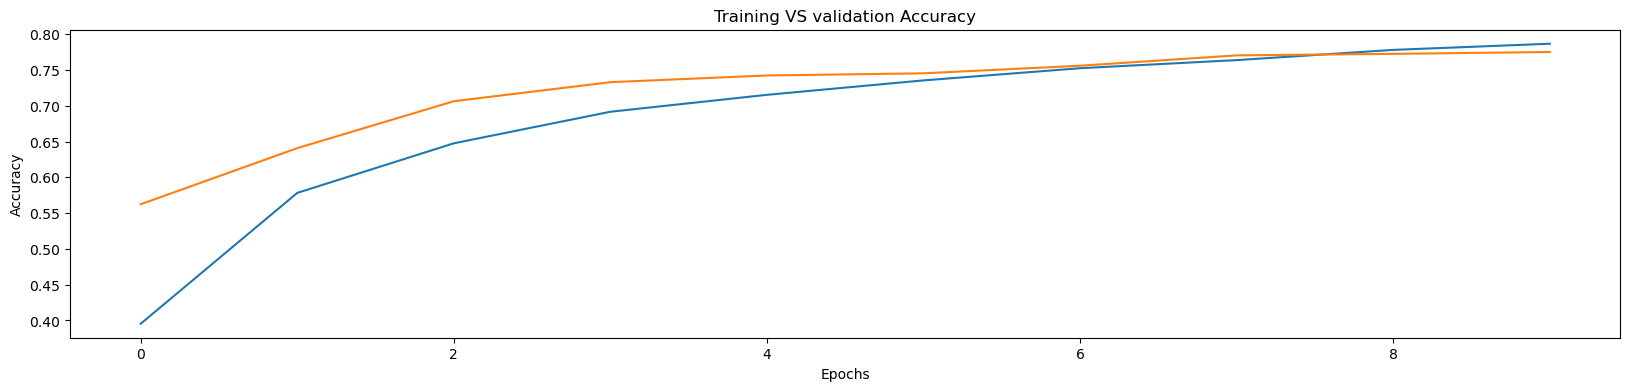

In [27]:
plt.figure(figsize=(20,4))
# accuracy plot
plt.plot(history.history["accuracy"], label= "Training Accuracy")
plt.plot(history.history["val_accuracy"], label= "validation Accuracy")
plt.title("Training VS validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

In [28]:
!pip install seaborn 

In [29]:
y_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step


In [30]:
# now,conveert predicted probabilites into final predicated class numbers 
# (0-9) by selecting highest va;ue 
y_pred_classes = y_pred.argmax(axis=1)

In [31]:
y_true=y_test.argmax(axis=1)

In [32]:
class_labels = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

In [33]:
!pip install scikit-learn

In [34]:
from sklearn.metrics import confusion_matrix

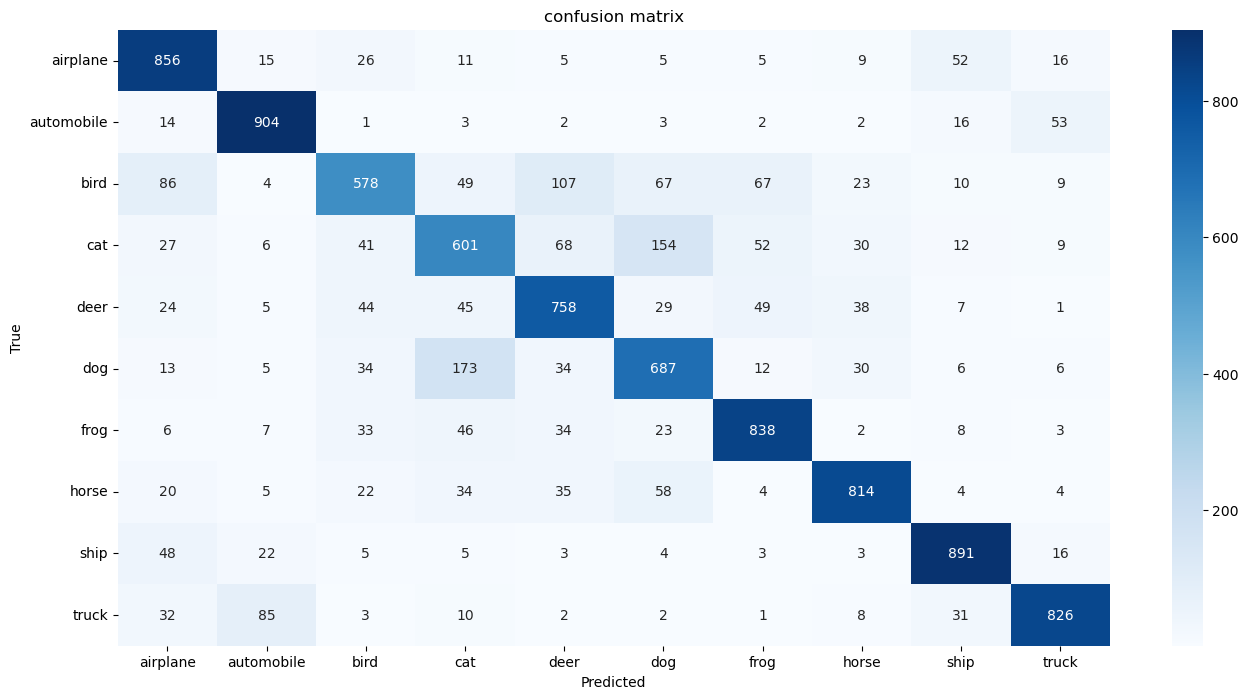

In [35]:
import seaborn as sns 
cm = confusion_matrix(y_true,y_pred_classes)
plt.figure(figsize=(16,8))
sns.heatmap(cm,annot= True,fmt='d',cmap='Blues',
            xticklabels = class_labels,yticklabels = class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('confusion matrix')
plt.show()

In [36]:
from sklearn.metrics import classification_report 

In [37]:
print(classification_report(y_true,y_pred_classes))

              precision    recall  f1-score   support

           0       0.76      0.86      0.81      1000
           1       0.85      0.90      0.88      1000
           2       0.73      0.58      0.65      1000
           3       0.62      0.60      0.61      1000
           4       0.72      0.76      0.74      1000
           5       0.67      0.69      0.68      1000
           6       0.81      0.84      0.82      1000
           7       0.85      0.81      0.83      1000
           8       0.86      0.89      0.87      1000
           9       0.88      0.83      0.85      1000

    accuracy                           0.78     10000
   macro avg       0.77      0.78      0.77     10000
weighted avg       0.77      0.78      0.77     10000



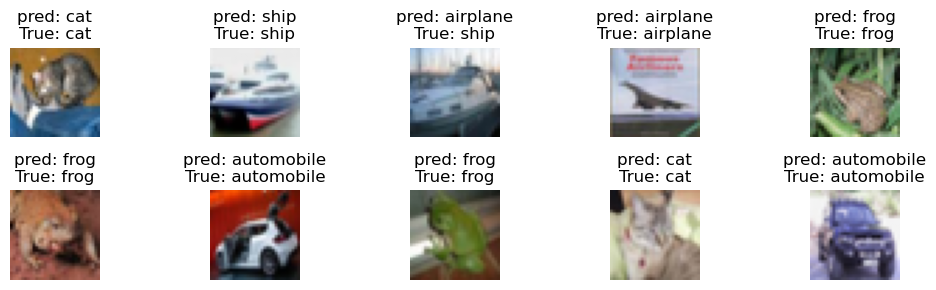

In [38]:
plt.figure(figsize=(12,3))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(32,32,3),cmap = 'gray')
    plt.title(f'pred: {class_labels[y_pred_classes[i]]}\nTrue: {class_labels[y_true[i]]}')
    plt.axis('off')
    plt.tight_layout()
plt.show() 

In [78]:
# Save model using Keras native format (recommended for CNN)
model.save('cifar10_model.keras')
print("Model saved successfully!")

Model saved successfully!
